<a href="https://colab.research.google.com/github/techbotsacademy/AI/blob/main/yolov8_license_plate_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Local Inference on GPU
Model page: https://huggingface.co/Koushim/yolov8-license-plate-detection

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/Koushim/yolov8-license-plate-detection)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
!pip install ultralytics opencv-python matplotlib pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.7 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded:", image_path)

Saving car1.jpg to car1.jpg
Uploaded: car1.jpg


In [4]:
!wget -O best.pt \
https://github.com/mendez-luisjose/License-Plate-Detection-with-YoloV8-and-EasyOCR/raw/main/models/license_plate_detector.pt

--2026-06-03 05:37:01--  https://github.com/mendez-luisjose/License-Plate-Detection-with-YoloV8-and-EasyOCR/raw/main/models/license_plate_detector.pt
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mendez-luisjose/License-Plate-Detection-with-YoloV8-and-EasyOCR/main/models/license_plate_detector.pt [following]
--2026-06-03 05:37:02--  https://raw.githubusercontent.com/mendez-luisjose/License-Plate-Detection-with-YoloV8-and-EasyOCR/main/models/license_plate_detector.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6241454 (6.0M) [application/octet-stream]
Saving to: ‘best.pt’

best.pt          

In [5]:
model = YOLO("best.pt")

print("Model loaded successfully")

Model loaded successfully


In [6]:
results = model.predict(
    source=image_path,
    conf=0.25,
    save=False
)

print("Detection complete")


image 1/1 /content/car1.jpg: 448x640 1 license_plate, 64.8ms
Speed: 14.2ms preprocess, 64.8ms inference, 38.9ms postprocess per image at shape (1, 3, 448, 640)
Detection complete


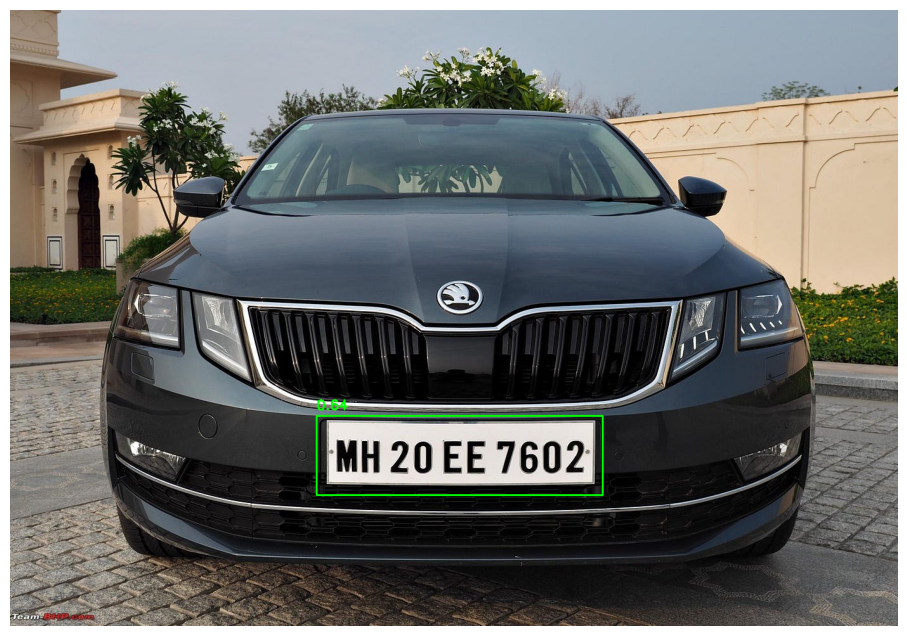

In [7]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

result = results[0]

for box in result.boxes:

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    confidence = float(box.conf[0])

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        image,
        f"{confidence:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0,255,0),
        2
    )

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.show()

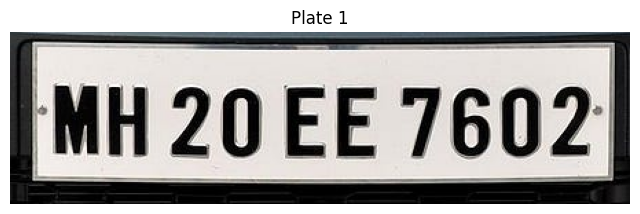

In [8]:
original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

result = results[0]

for idx, box in enumerate(result.boxes):

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate_crop = original[y1:y2, x1:x2]

    plt.figure(figsize=(8,3))
    plt.imshow(plate_crop)
    plt.title(f"Plate {idx+1}")
    plt.axis("off")
    plt.show()

In [9]:
import os

os.makedirs("plates", exist_ok=True)

for idx, box in enumerate(result.boxes):

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    crop = original[y1:y2, x1:x2]

    filename = f"plates/plate_{idx+1}.jpg"

    cv2.imwrite(
        filename,
        cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
    )

    print("Saved:", filename)

Saved: plates/plate_1.jpg


In [10]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 27.4 MB/s eta 0:00:00


In [11]:
import easyocr

reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [12]:
for idx, box in enumerate(result.boxes):

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    crop = original[y1:y2, x1:x2]

    text = reader.readtext(crop)

    print(f"\nPlate {idx+1}")

    for item in text:
        print(item[1])


Plate 1
MH 20 EE 7602
